# <h1 style="text-align: center;">Optimal Control of TCLab using a Gaussian process regression embedded in Pyomo</h1>

<h2 style="text-align: center;">Notebook v7</h2>

<p style="text-align: center;">Alex Dowling<sup>a</sup>, Jacob P. Krell<sup>b</sup>, David S. Mebane<sup>b</sup>

<p style="text-align: center;"><sup>a</sup>Department of Chemical and Biomolecular Engineering, University of Notre Dame, Notre Dame, IN 46556, USA <br>
<sup>b</sup>Department of Mechanical and Aerospace Engineering, West Virginia University, Morgantown, WV, 26506-6106, USA</p>

## Change Log

- adapted from *pyomo_tclab_v6_optimize1_with_v5c2.ipynb*
- previously internal ```fokl_to_pyomo``` function accessed through updated FoKL module

## Script

In [1]:
from FoKL import FoKLRoutines
import os
dir = os.path.abspath('')  # directory of notebook
# -----------------------------------------------------------------------
# UNCOMMENT IF USING LOCAL FOKL PACKAGE:
import sys
sys.path.append(os.path.join(dir, '..', '..'))  # package directory
from src.FoKL import FoKLRoutines
# -----------------------------------------------------------------------
import pandas as pd
from scipy.interpolate import interp1d
import numpy as np
import pyomo.environ as pyo
import pyomo.dae as dae
import matplotlib.pyplot as plt

In [2]:
# =====================================================================
# =====================================================================
# LOAD AND PARSE SINE TEST DATA:

data = pd.read_csv(os.path.join(dir, "data", "tclab_sine_test.csv"))

tvec = data["Time"].values
Q1 = data["Q1"].values
TS1 = data["T1"].values

Q1f = interp1d(tvec, Q1, kind='previous')  # piecewise Q1
dQ1f_analytic = lambda t: 1500 * np.cos(30 * np.pi * t / tvec[-1]) * np.pi / tvec[-1]  # derivative of analytic Q1
dQ1f = interp1d(tvec, dQ1f_analytic(tvec), kind='previous')  # piecewise derivative of analytic Q1

In [3]:
# =====================================================================
# =====================================================================
# SMOOTHING OF SINE TEST:

window = 9  # odd number, mean at center +/- floor(window/2))

def smooth(TS1, window):
    """Apply centered average of size window."""
    TS1_smooth = np.zeros_like(TS1)
    w2 = int(np.floor(window / 2))
    w2p1 = w2 + 1

    # bleed in:
    for i in range(w2):
        TS1_smooth[i] = np.mean(TS1[:(i + w2p1)])

    # center:
    for i in range(w2, TS1_smooth.size - w2):
        TS1_smooth[i] = np.mean(TS1[(i - w2):(i + w2p1)])

    # bleed out:
    for i in range(-w2, 0):
        TS1_smooth[i] = np.mean(TS1[(i - w2)::])

    return TS1_smooth

TS1_smooth = smooth(TS1, window)

In [4]:
# =====================================================================
# =====================================================================
# DERIVATIVE OF SMOOTHED SINE TEST:

def gradient_h4(x, h):
    """h is step size. Order of error is h^4."""
    dx = np.zeros_like(x)

    # bleed in:
    h2 = 2 * h
    dx[0] = (x[1] - x[0]) / h
    dx[1] = (x[2] - x[0]) / h2

    # center difference:
    h12 = 12 * h
    for i in range(2, x.shape[0] - 2):
        dx[i] = (x[i - 2] - 8 * x[i - 1] + 8 * x[i + 1] - x[i + 2]) / h12
    
    # bleed out:
    dx[-2] = (x[-1] - x[-3]) / h2
    dx[-1] = (x[-1] - x[-2]) / h

    return dx

dTS1 = gradient_h4(TS1_smooth, tvec[1] - tvec[0])
dTS1f = interp1d(tvec, dTS1, kind='previous')  # piecewise, grab previous value

In [5]:
# =====================================================================
# =====================================================================
# GP MODEL OF DIFFERENTIATED SINE TEST:

try:
    GP_dT = FoKLRoutines.load(os.path.join("models", "pyomo_tclab_v7.fokl"))
except Exception as exception:
    GP_dT = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True)
    GP_dT.fit([TS1_smooth, Q1, dQ1f(tvec)], dTS1, clean=True)
    GP_dT.save(os.path.join("models", "pyomo_tclab_v7.fokl"))

In [6]:
# =====================================================================
# =====================================================================
# CONTROLLER REFERENCE TRAJECTORY:

# time grid
t0 = 0
tf = 1000
dt = 2
n = round(tf / dt)
t_grid = np.linspace(t0, tf, n + 1)

# ambient temperature
Tamb = 21.0

# setpoint/reference
def r(t):
    return np.interp(t, [0, 50, 150, 450, 550], [Tamb, Tamb, 60, 60, 35])

In [7]:
# =====================================================================
# =====================================================================
# OPTIMIZATION USING GP MODEL - CREATION OF PYOMO MODEL:

# Create a Pyomo model
m = pyo.ConcreteModel('TCLab Heater with GP Model')

# Define time domain
m.t = dae.ContinuousSet(bounds=(t0, tf))

# Define the state variables as a function of time
m.Ts1 = pyo.Var(m.t)

# Define the control variable (heater power) as a function of time
m.u1 = pyo.Var(m.t, bounds=(0, 100))  # != Q1f(t0)

# Define the derivative of the control variable
m.du1 = dae.DerivativeVar(m.u1)  # != dQ1f(t0)

# Define the derivatives of the state variables
m.dTs1 = dae.DerivativeVar(m.Ts1)

# Fix the initial conditions
m.Ts1[t0].fix(Tamb)
m.dTs1[t0].fix(0.0)
m.u1[t0].fix(0.0)
m.du1[t0].fix(0.0)

# Arguments to embed GP in Pyomo model:
xvars = [m.Ts1, m.u1, m.du1]
yvar = m.dTs1
draws = 5

# Embed GP:
GP_dT.to_pyomo(xvars, yvar, m, draws)

# Define the integral of the squared error
@m.Integral(m.t)
def ise(m, t):
    return (r(t) - m.Ts1[t]) ** 2

# Define the objective function
@m.Objective(sense=pyo.minimize)
def objective(m):
    return m.ise

m.pprint()

2 Var Declarations
    Ts1 : Size=2, Index=t
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
           0 :  None :  21.0 :  None :  True : False :  Reals
        1000 :  None :  None :  None : False :  True :  Reals
    u1 : Size=2, Index=t
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
           0 :     0 :   0.0 :   100 :  True : False :  Reals
        1000 :     0 :  None :   100 : False :  True :  Reals

1 Objective Declarations
    objective : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : minimize :        ise

1 Block Declarations
    GP0 : Size=1, Index=None, Active=True
        4 Set Declarations
            attributes : Size=1, Index=None, Ordered=Insertion
                Key  : Dimen : Domain : Size : Members
                None :     1 :    Any :    3 : {0, 1, 2}
            draws : Size=1, Index=None, Ordered=Insertion
                Key  : Dimen : Domain : Size : Members
             

Ipopt 3.14.16: 
Exception of type: DYNAMIC_LIBRARY_FAILURE in file "Common/IpLibraryLoader.cpp" at line 86:
 Exception message: libhsl.so: cannot open shared object file: No such file or directory

EXIT: Library loading failure.
model.name="TCLab Heater with GP Model";
    - termination condition: other
    - message from solver: <undefined>


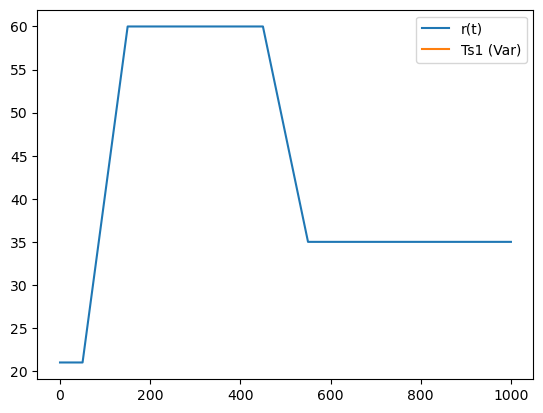

In [8]:
# =====================================================================
# =====================================================================
# OPTIMIZATION USING GP MODEL - SOLVER:

# Apply a collocation method to numerically integrate the differential equations
pyo.TransformationFactory('dae.collocation').apply_to(m, nfe=200, wrt=m.t)

# Call our nonlinear optimization/equation solver, Ipopt
pyo.SolverFactory('ipopt').solve(m, tee=True)

# Print solution
tvec = m.t.data()
plt.figure()
plt.plot(tvec, r(tvec))
plt.plot(tvec, m.Ts1[:]())
plt.legend(['r(t)', 'Ts1 (Var)'])
plt.show()